# Parallel Node execution

## Review:
- Summerize the llm generation using memory
- Using Human in the loop ,  create
    - Approval -  stttic and Dynamic interrupts to get user feedback and approval
    - Debugging - rewind the graph usign state history to fork and replay to reproduce or avaoid issues
    - editing - modify the state for operations

## Goals: Multi- agent workflow
- Using Human in the loop and memory build a multi agent research assistant 
- Use all the modules learned so far
- Learn fan in and fan out
- Parallalization - nodes running in parallel

### Parallelization = letting multiple nodes run at once when they’re independent.
In LangGraph (and similar agent frameworks):

#### Sequential:  
- Node A → Node B → Node C (one after another)

#### Parallel:  
- Node A → Node B
     ↘ Node C
  B and C can run at the same time if:

- they both have enough info in the state, and
- they don’t depend on each other’s outputs.

# Fan-In and Fan-Out


#### Build a simple linear graph that overwrites the steps 

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [2]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

In [3]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [4]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHo6HNHbtjH8eOOv/tdD4Yc3egu4WiWQPZu4zLvlU7g4cGQ4v29rcyymmASyNc'}}]

## Build a simple linear graph using node classes
A Python class that implements `__call__`, so it behaves like a function.

### 🧠 Why do node classes exist?
Because sometimes a node needs to remember something.
- A plain function:
- has no memory
- has no configuration
- behaves the same every time

A node class:
- stores configuration in __init__
- uses that configuration in __call__
- lets you create many different nodes from one class

This is the key idea:
- Functions are stateless.
- Node classes are stateful.


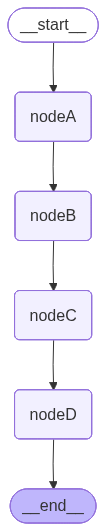

In [7]:
from IPython.display import Image, display

from typing import List, TypedDict
from langgraph.graph import StateGraph , START, END

# build a class to update summary

class State(TypedDict):
    summary: List[str]

# build node classes
class UpdateSummary:
    def __init__(self, node_data:str):
        self._value = node_data

    def __call__(self, state:State):
        print(f"Updating the state summary: {state['summary']} with value: {self._value}")
        return {'summary': [self._value]}

# BUild a graph
builder = StateGraph(State)

# add nodes and edges
# Initialize each node with node_data
data = ["A", "B", "C", "D"]
for item in data:
    builder.add_node(f'node{item}', UpdateSummary(item))

# add flow
builder.set_entry_point('nodeA')
builder.add_edge('nodeA', 'nodeB')
builder.add_edge('nodeB', 'nodeC')
builder.add_edge('nodeC', 'nodeD')
builder.add_edge('nodeD', END)

# compile
graph= builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

#### state is over written everytime

Final Summary = D

In [8]:
graph.invoke({'summary': []})

Updating the state summary: [] with value: A
Updating the state summary: ['A'] with value: B
Updating the state summary: ['B'] with value: C
Updating the state summary: ['C'] with value: D


{'summary': ['D']}

## Parallelization 
Run B and C in parallel and then D|

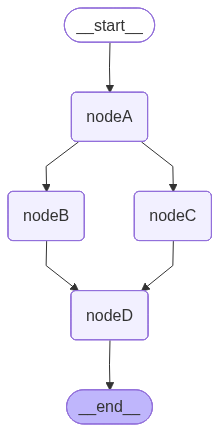

In [9]:
# BUild a graph
builder = StateGraph(State)

# add nodes and edges
# Initialize each node with node_data
data = ["A", "B", "C", "D"]
for item in data:
    builder.add_node(f'node{item}', UpdateSummary(f"I am {item}"))

# add flow
builder.set_entry_point('nodeA')
builder.add_edge('nodeA', 'nodeB')
builder.add_edge('nodeA', 'nodeC')
builder.add_edge('nodeB', 'nodeD')
builder.add_edge('nodeC', 'nodeD')
builder.add_edge('nodeD', END)

# compile
graph= builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## Throws an error as both nodes B and C try to write to the kye 'summary'

In [13]:
from langgraph.errors import InvalidUpdateError

try:
    graph.invoke({"summary": []})
except InvalidUpdateError as e:
    print("\n InvalidUpdateError : At key 'summary': Can receive only one value per step. Use an Annotated key to handle multiple values.")

Updating the state summary: [] with value: I am A
Updating the state summary: ['I am A'] with value: I am B
Updating the state summary: ['I am A'] with value: I am C

 InvalidUpdateError : At key 'summary': Can receive only one value per step. Use an Annotated key to handle multiple values.


## Fan Out: when fanning out ensure to use reducers which appends the data to the key field instead of overwrititng to avoid errors if steps are writing to the same the channel / key.

## Reducer:  
    - Use python built in operator module 'add' to append the list.
   -  When `operator.add` is applied to lists, it performs list concatenation.

**Build a graph using a reducer**

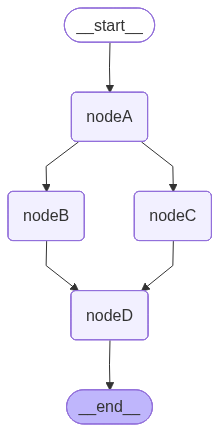

In [14]:
from operator import add
from typing import Annotated

# define state
class State(TypedDict):
    summary: Annotated[List[str], add]

# using old node functions, build a graph

builder = StateGraph(State)

# Initialize each node with node_data
data = ["A", "B", "C", "D"]
for item in data:
    builder.add_node(f'node{item}', UpdateSummary(f"I am {item}"))

# add flow

builder.set_entry_point('nodeA')
builder.add_edge('nodeA', 'nodeB')
builder.add_edge('nodeA', 'nodeC')
builder.add_edge('nodeB', 'nodeD')
builder.add_edge('nodeC', 'nodeD')
builder.add_edge('nodeD', END)

# compile
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
            

In [15]:
graph.invoke({"summary": []})

Updating the state summary: [] with value: I am A
Updating the state summary: ['I am A'] with value: I am B
Updating the state summary: ['I am A'] with value: I am C
Updating the state summary: ['I am A', 'I am B', 'I am C'] with value: I am D


{'summary': ['I am A', 'I am B', 'I am C', 'I am D']}

 reducer appends the data which helps preserve state at parallel nodes

## Waiting for the Node to complete 

Lets consider a case where one parallel path has more steps than the other one.

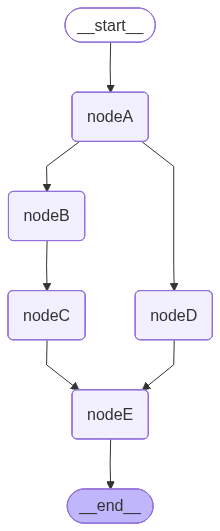

In [17]:
builder = StateGraph(State)
# Initialize each node with node_data
data = ["A", "B", "C", "D", "E"]
for item in data:
    builder.add_node(f'node{item}', UpdateSummary(f"I am {item}"))

# add flow

builder.set_entry_point('nodeA')
builder.add_edge('nodeA', 'nodeB')
builder.add_edge('nodeB', 'nodeC')
builder.add_edge('nodeA', 'nodeD')
builder.add_edge('nodeC', 'nodeE')
builder.add_edge('nodeD', 'nodeE')
builder.add_edge('nodeE', END)

graph =builder.compile()

graph

In [18]:
graph.invoke({"summary": []})

Updating the state summary: [] with value: I am A
Updating the state summary: ['I am A'] with value: I am B
Updating the state summary: ['I am A'] with value: I am D
Updating the state summary: ['I am A', 'I am B', 'I am D'] with value: I am C
Updating the state summary: ['I am A', 'I am B', 'I am D'] with value: I am E
Updating the state summary: ['I am A', 'I am B', 'I am D', 'I am C', 'I am E'] with value: I am E


{'summary': ['I am A', 'I am B', 'I am D', 'I am C', 'I am E', 'I am E']}

## Custom reducer to set the order of the state update
```
def sorting_reducer(left, right):
    """ Combines and sorts the values in a list"""
    if not isinstance(left, list):
        left = [left]

    if not isinstance(right, list):
        right = [right]
    
    return sorted(left + right, reverse=False)
```

####  e.g., sort state updates.:
```
class State(TypedDict):
    # sorting_reducer will sort the values in state
    state: Annotated[list, sorting_reducer]
```

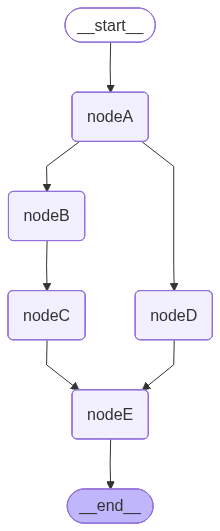

In [22]:
def sorting_reducer(left, right):
    """ Combines and sorts the values in a list"""
    if not isinstance(left, list):
        left = [left]

    if not isinstance(right, list):
        right = [right]
    
    return sorted(left + right, reverse=False)

class State(TypedDict):
    # sorting_reducer will sort the values in state
    summary: Annotated[list, sorting_reducer]



builder = StateGraph(State)
# Initialize each node with node_data
data = ["A", "B", "C", "D", "E"]
for item in data:
    builder.add_node(f'node{item}', UpdateSummary(f"I am {item}"))

# add flow

builder.set_entry_point('nodeA')
builder.add_edge('nodeA', 'nodeB')
builder.add_edge('nodeB', 'nodeC')
builder.add_edge('nodeA', 'nodeD')
builder.add_edge('nodeC', 'nodeE')
builder.add_edge('nodeD', 'nodeE')
builder.add_edge('nodeE', END)

graph =builder.compile()

graph

In [23]:
graph.invoke({"summary": []})

Updating the state summary: [] with value: I am A
Updating the state summary: ['I am A'] with value: I am B
Updating the state summary: ['I am A'] with value: I am D
Updating the state summary: ['I am A', 'I am B', 'I am D'] with value: I am C
Updating the state summary: ['I am A', 'I am B', 'I am D'] with value: I am E
Updating the state summary: ['I am A', 'I am B', 'I am C', 'I am D', 'I am E'] with value: I am E


{'summary': ['I am A', 'I am B', 'I am C', 'I am D', 'I am E', 'I am E']}